In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("Zomato-data-.csv")

In [4]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [6]:
def handleRate(value):
    value = str(value).split('/')
    value = value[0]
    return float(value)
    

In [7]:
df['rate'] = df['rate'].apply(handleRate)

In [9]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [10]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


In [12]:
# Data is cleaned and preprocessed now time for exploring the data

# Exploring Restaurant types

Text(0.5, 0, 'Types of Restaurant')

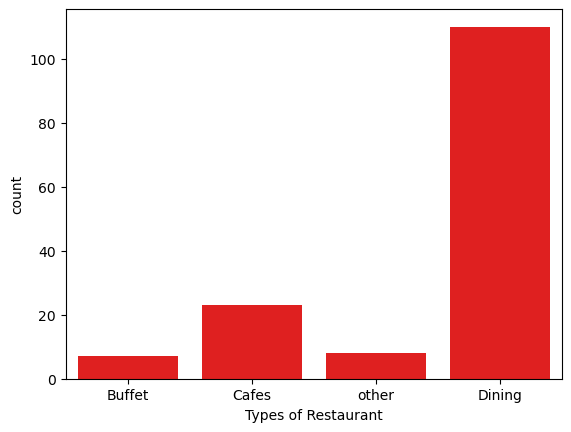

In [31]:
sns.countplot(x = df['listed_in(type)'],color ='red')
plt.xlabel("Types of Restaurant")
              

In [14]:
# Conclusion: Majority of restaurant falls into Dining Category

# Total Numbers of votes by Restaurant Type

In [16]:
grouped_data = df.groupby('listed_in(type)')['votes'].sum()
grouped_data

listed_in(type)
Buffet     3028
Cafes      6434
Dining    20363
other      9367
Name: votes, dtype: int64

Text(0, 0.5, 'Number of Votes')

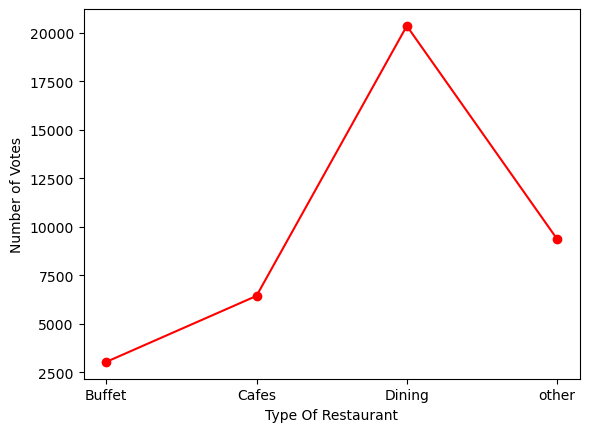

In [19]:
result = pd.DataFrame({'votes':grouped_data})
plt.plot(result, color ='red',marker = 'o')
plt.xlabel("Type Of Restaurant")
plt.ylabel("Number of Votes")

In [20]:
# Conclusion: Dining restaurants are prefered by large number of customers

# Identify the most voted restaurant

In [24]:
max_votes = df['votes'].max()
res_with_max_votes = df.loc[df['votes'] == max_votes, 'name']
print("Restaurant with max votes : ")
print(res_with_max_votes)

Restaurant with max votes : 
38    Empire Restaurant
Name: name, dtype: object


In [25]:
# Empire restaurant is a restaurant with the max votes of 38

# Online availability

<Axes: xlabel='online_order', ylabel='count'>

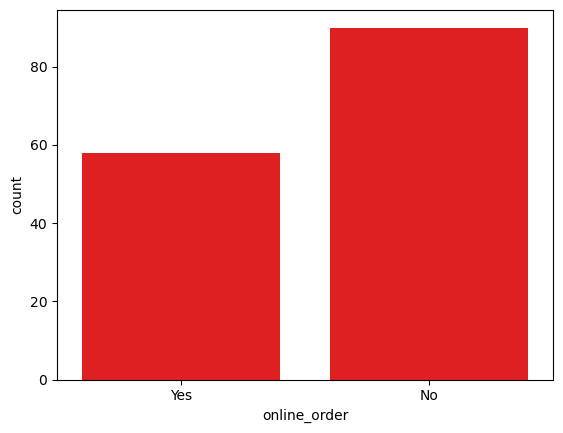

In [27]:
sns.countplot(x=df['online_order'], color='red')


In [28]:
# Conclusion: This tells that the majority of restaurants do not have online order system

# Ratings Analysis

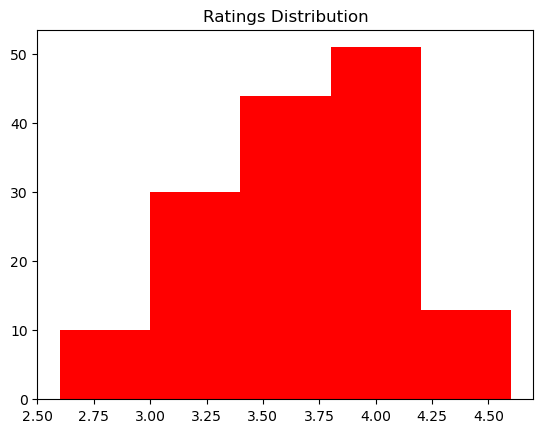

In [30]:
plt.hist(df['rate'],bins=5,color = 'red')
plt.title('Ratings Distribution')
plt.show()

In [32]:
# Conclusion: The majority of restaurants have ratings between 3.5 and 4.25

# Approximate Cost for couples

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

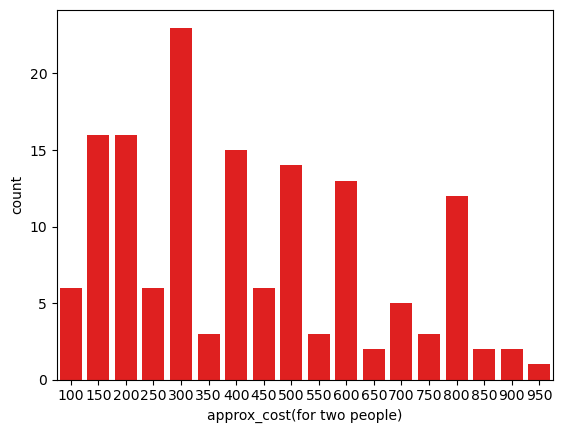

In [35]:
couple_data = df['approx_cost(for two people)']
sns.countplot(x=couple_data, color = 'red')

In [36]:
# Conclusion: The majority of couple prefer restaurant with approximate cost of 300

# Rating Comparison between Online and Offline Orders

<Axes: xlabel='online_order', ylabel='rate'>

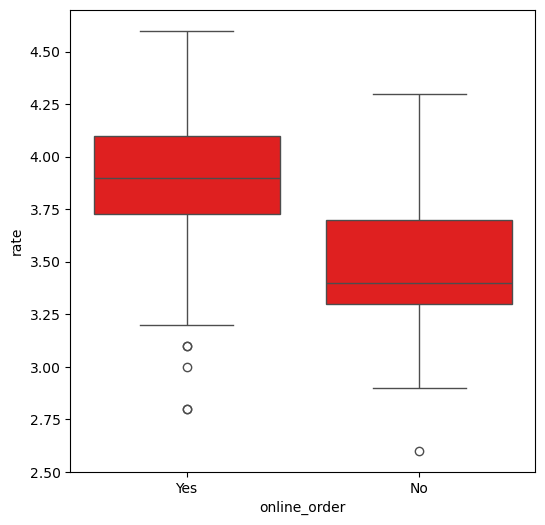

In [38]:
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order', y= 'rate' , data = df, color = 'red')

In [39]:
# Conclusion: Offline orders received lower ratings as compared to online orders which have high ratings

# Mode of Order Preference by Resaturant Type

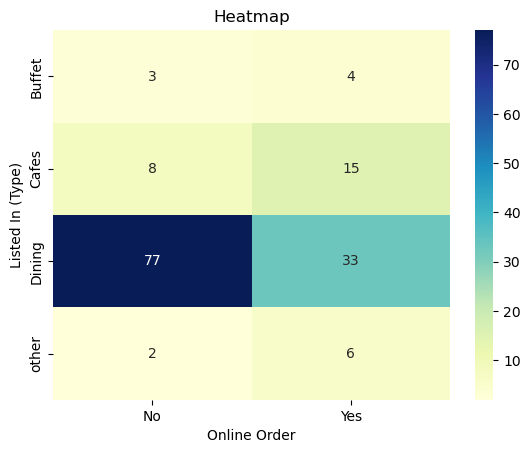

In [40]:
pivot_table = df.pivot_table(index = 'listed_in(type)',columns = 'online_order', aggfunc = 'size',fill_value='0')
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()

In [41]:
# Conclusion: Dining Restaurants accept more offline orders whereas cafes receive more online order.